<a href="https://colab.research.google.com/github/Didarulisalmdidar/QLSTM_Multilayer_Network/blob/main/4_IntraSectorWeight%26AdjacencyMatrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane pennylane-lightning networkx -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 21.4 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
import networkx as nx

BASE_DIR    = "/content/drive/MyDrive/MSC Thesis"
MODEL_DIR   = os.path.join(BASE_DIR, "Models_Dense")
WEIGHT_DIR  = os.path.join(BASE_DIR, "BDWeightMatrices_Dense")
ADJ_DIR     = os.path.join(BASE_DIR, "BDAdjacencyMatrices_Dense")
METRICS_DIR = os.path.join(BASE_DIR, "BDNetworkMetrics_Dense")
PLOT_DIR    = os.path.join(BASE_DIR, "BDPlots_Dense")

for d in [WEIGHT_DIR, ADJ_DIR, METRICS_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

SECTORS = ["Energy", "IT", "Financial", "Healthcare"]

SECTOR_TICKERS = {
    "Energy"    : ["APA","COP","CVX","DVN","EOG","FLR","FTI",
                   "HAL","NFG","OKE","OXY","SLB","VLO","WMB","XOM"],
    "IT"        : ["AAPL","MSFT","NVDA","ORCL","CRM","AMD","QCOM",
                   "TXN","INTC","IBM","CSCO","AMAT","ADI","MU","ADBE"],
    "Financial" : ["JPM","BAC","WFC","GS","MS","C","BLK","SCHW",
                   "AXP","USB","PNC","COF","BK","STT","CME"],
    "Healthcare": ["JNJ","UNH","LLY","ABT","TMO","MRK","DHR","ABBV",
                   "PFE","BMY","AMGN","GILD","SYK","MDT","BSX"],
}

CRISIS_PERIODS = [
    (2008, 2009, "#FF6B6B", "GFC 2008"),
    (2011, 2012, "#FF9500", "ESD 2011-12"),
    (2015, 2016, "#2ECC71", "Global Decline 2015"),
    (2020, 2021, "#FFA500", "COVID-19 2020"),
    (2022, 2023, "#9B59B6", "Russia-Ukraine 2022"),
]

N_QUBITS   = 4
N_LAYERS   = 2
N_STOCKS   = 15
HIDDEN_DIM = 4

In [ ]:
# ── Model definition ───────────────────────────────────────
# ─────────────────────────────────────────────
# VQC — VARIATIONAL QUANTUM CIRCUIT
# ─────────────────────────────────────────────
try:
    dev = qml.device("lightning.qubit", wires=N_QUBITS)
    DIFF_METHOD = "adjoint"
except:
    dev = qml.device("default.qubit", wires=N_QUBITS)
    DIFF_METHOD = "backprop"

def vqc(inputs, weights):
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.CNOT(wires=[N_QUBITS - 1, 0])
    for l in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

qnode = qml.QNode(vqc, dev, interface="torch",
                  diff_method=DIFF_METHOD)

class QuantumLSTMCell(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_dim        = HIDDEN_DIM
        self.input_proj        = nn.Linear(N_STOCKS + HIDDEN_DIM, N_QUBITS)
        self.weights_forget    = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.weights_input     = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.weights_candidate = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.weights_output    = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.output_proj       = nn.Linear(HIDDEN_DIM, N_STOCKS)
    def forward_gate(self, projected, weights):
        results = []
        for b in range(projected.shape[0]):
            out = qnode(projected[b], weights)
            out_tensor = out.float() if isinstance(out, torch.Tensor) \
                         else torch.stack(out).float()
            results.append(out_tensor)
        return torch.stack(results)
    def forward(self, x_t, h_t, c_t):
        combined  = torch.cat([x_t, h_t], dim=-1)
        projected = torch.tanh(self.input_proj(combined)) * torch.pi
        f_t = torch.sigmoid(self.forward_gate(projected, self.weights_forget))
        i_t = torch.sigmoid(self.forward_gate(projected, self.weights_input))
        g_t = torch.tanh(self.forward_gate(projected,    self.weights_candidate))
        o_t = torch.sigmoid(self.forward_gate(projected, self.weights_output))
        c_new = f_t * c_t + i_t * g_t
        h_new = o_t * torch.tanh(c_new)
        return h_new, c_new, self.output_proj(h_new)

class QuantumLSTMAutoencoderDense(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_dim = HIDDEN_DIM
        self.cell  = QuantumLSTMCell()
        self.dense = nn.Linear(N_STOCKS, N_STOCKS, bias=False)
    def forward(self, x):
        h_t = torch.zeros(x.shape[0], self.hidden_dim)
        c_t = torch.zeros(x.shape[0], self.hidden_dim)
        recons = []
        for t in range(x.shape[1]):
            h_t, c_t, recon = self.cell(x[:, t, :], h_t, c_t)
            recon = self.dense(recon)
            recons.append(recon)
        return torch.stack(recons, dim=1)

print("✅ Model definition ready")

✅ Model definition ready


In [ ]:
# ══════════════════════════════════════════════════════════
# PHASE 5 — W Matrix Extraction
# ══════════════════════════════════════════════════════════

def extract_W(model):
    """Absolute value normalization |W| following Tuhin et al. (2025)"""
    with torch.no_grad():
        W = model.dense.weight.detach().numpy()
    W_abs  = np.abs(W)                                          # ← take absolute value
    W_norm = (W_abs - W_abs.min()) / (W_abs.max() - W_abs.min() + 1e-8)  # ← min-max normalize
    return W_norm


def extract_all_weights():
    print("\n" + "="*60)
    print(" Phase 5 — W Matrix Extraction (Dense + Signed)")
    print("="*60)

    for sector in SECTORS:
        tickers    = SECTOR_TICKERS[sector]
        sector_dir = os.path.join(WEIGHT_DIR, sector)
        os.makedirs(sector_dir, exist_ok=True)
        print(f"\n── {sector} ──────────────────────────")

        for year_idx in range(20):
            year_label  = 2005 + year_idx
            model_path  = os.path.join(MODEL_DIR, sector,
                                       f"year_{year_idx:02d}.pt")
            csv_path    = os.path.join(sector_dir,
                                       f"year_{year_idx:02d}.csv")

            if not os.path.exists(model_path):
                print(f"  {year_label}: ⚠️ model not found")
                continue

            model = QuantumLSTMAutoencoderDense()
            model.load_state_dict(torch.load(
                model_path, map_location="cpu"))
            model.eval()

            W_norm = extract_W(model)
            W_df   = pd.DataFrame(W_norm,
                                  index=tickers,
                                  columns=tickers)
            W_df.to_csv(csv_path)
            print(f"  {year_label}: τ={W_norm.mean():.4f}  "
                  f"saved ✅")

    print("\n✅ Phase 5 complete")


In [ ]:
# ══════════════════════════════════════════════════════════
# PHASE 6 — Threshold τ Evolution Plot
# ══════════════════════════════════════════════════════════

def plot_tau_all_sectors():
    print("\n" + "="*60)
    print(" Phase 6 — Threshold τ Evolution")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Mean Threshold τ Over Time — All Sectors\n"
                 "(Dense Bottleneck + Signed Normalization)",
                 fontsize=14, fontweight="bold")

    sector_colors = {
        "Energy"    : "#EF9F27",
        "IT"        : "#378ADD",
        "Financial" : "#1D9E75",
        "Healthcare": "#7F77DD",
    }

    all_tau = {}

    for ax, sector in zip(axes.flatten(), SECTORS):
        sector_dir = os.path.join(WEIGHT_DIR, sector)
        years, taus = [], []

        for year_idx in range(20):
            year_label = 2005 + year_idx
            csv_path   = os.path.join(sector_dir,
                                      f"year_{year_idx:02d}.csv")
            if not os.path.exists(csv_path):
                continue
            W    = pd.read_csv(csv_path, index_col=0).values
            tau  = W.mean()
            years.append(year_label)
            taus.append(round(tau, 4))

        all_tau[sector] = dict(zip(years, taus))
        color = sector_colors[sector]

        ax.plot(years, taus, color=color, linewidth=2.5,
                marker="o", markersize=6,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=2, zorder=3)
        ax.fill_between(years, taus, alpha=0.08, color=color)

        for y, t in zip(years, taus):
            ax.annotate(f"{t:.3f}", xy=(y, t), xytext=(0, 8),
                        textcoords="offset points",
                        ha="center", fontsize=7)

        for start, end, ccolor, clabel in CRISIS_PERIODS:
            ax.axvspan(start, end, alpha=0.08, color=ccolor,
                       label=clabel)

        mean_tau = np.mean(taus)
        ax.axhline(y=mean_tau, color="gray", linewidth=1,
                   linestyle=":", label=f"Mean={mean_tau:.3f}")

        ax.set_title(f"{sector}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Year", fontsize=9)
        ax.set_ylabel("Mean Threshold τ", fontsize=9)
        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45, fontsize=7)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize=7, loc="upper left")

        print(f"\n  {sector}:")
        print(f"    Mean τ : {mean_tau:.4f}")
        print(f"    Max τ  : {max(taus):.4f} ({years[taus.index(max(taus))]})")
        print(f"    Min τ  : {min(taus):.4f} ({years[taus.index(min(taus))]})")

    plt.tight_layout()
    local = "/content/tau_all_sectors_dense.png"
    plt.savefig(local, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    save_path = os.path.join(PLOT_DIR, "tau_all_sectors_dense.png")
    try:
        shutil.copy(local, save_path)
        os.remove(local)
        print(f"\n  Plot saved → {save_path}")
    except:
        print(f"  ⚠️ Plot kept locally: {local}")

    print("\n✅ Phase 6 complete")
    return all_tau

In [ ]:
# ══════════════════════════════════════════════════════════
# PHASE 7 — Adjacency Matrix Construction
# ══════════════════════════════════════════════════════════

def build_adjacency_all():
    print("\n" + "="*60)
    print(" Phase 7 — Adjacency Matrix Construction")
    print("="*60)

    summary_all = {}

    for sector in SECTORS:
        tickers    = SECTOR_TICKERS[sector]
        weight_dir = os.path.join(WEIGHT_DIR, sector)
        adj_dir    = os.path.join(ADJ_DIR, sector)
        os.makedirs(adj_dir, exist_ok=True)

        print(f"\n── {sector} ──────────────────────────")

        # Compute fixed threshold θ = μ_all + σ_all
        all_values = []
        for year_idx in range(20):
            csv_path = os.path.join(weight_dir,
                                    f"year_{year_idx:02d}.csv")
            if os.path.exists(csv_path):
                W = pd.read_csv(csv_path, index_col=0).values
                all_values.append(np.abs(W).flatten())

        if not all_values:
            continue

        all_vals = np.concatenate(all_values)
        mu_all   = all_vals.mean()
        sig_all  = all_vals.std()
        theta    = mu_all + sig_all
        print(f"  θ_fixed = {mu_all:.4f} + {sig_all:.4f} = {theta:.4f}")

        results = []

        for year_idx in range(20):
            year_label = 2005 + year_idx
            csv_path   = os.path.join(weight_dir,
                                      f"year_{year_idx:02d}.csv")
            adj_csv    = os.path.join(adj_dir,
                                      f"year_{year_idx:02d}.csv")

            if not os.path.exists(csv_path):
                continue

            W_df = pd.read_csv(csv_path, index_col=0)
            W    = np.abs(W_df.values)   # use |W| for threshold

            # Binary adjacency: A[i][j] = 1 if |W[i][j]| > θ
            A    = (W > theta).astype(int)
            np.fill_diagonal(A, 0)
            A_df = pd.DataFrame(A, index=tickers, columns=tickers)
            A_df.to_csv(adj_csv)

            n_edges = int(A.sum())
            density = n_edges / (N_STOCKS * (N_STOCKS - 1))
            results.append({
                "year"   : year_label,
                "theta"  : round(theta, 4),
                "edges"  : n_edges,
                "density": round(density, 3),
            })
            print(f"  {year_label}: edges={n_edges}  "
                  f"density={density:.3f}  ✅")

        if results:
            summary_df = pd.DataFrame(results)
            summary_df.to_csv(
                os.path.join(adj_dir, "summary.csv"), index=False)
            summary_all[sector] = summary_df
            print(f"  Mean density: {summary_df['density'].mean():.3f}")
            print(f"  Max density : {summary_df['density'].max():.3f} "
                  f"({int(summary_df.loc[summary_df['density'].idxmax(),'year'])})")

    print("\n✅ Phase 7 complete")
    return summary_all

In [ ]:
# ══════════════════════════════════════════════════════════
# PHASE 8 — Network Metrics
# ══════════════════════════════════════════════════════════

def avg_shortest_path(G):
    U = G.to_undirected()
    if U.number_of_edges() == 0:
        return 0.0
    lengths = []
    for comp in nx.connected_components(U):
        if len(comp) < 2:
            continue
        try:
            lengths.append(
                nx.average_shortest_path_length(U.subgraph(comp)))
        except:
            pass
    return round(float(np.mean(lengths)), 4) if lengths else 0.0


def compute_metrics_all():
    print("\n" + "="*60)
    print(" Phase 8 — Network Metrics")
    print("="*60)

    all_metrics = {}

    for sector in SECTORS:
        adj_dir     = os.path.join(ADJ_DIR, sector)
        metrics_dir = os.path.join(METRICS_DIR, sector)
        os.makedirs(metrics_dir, exist_ok=True)

        print(f"\n── {sector} ──────────────────────────")
        results = []

        for year_idx in range(20):
            year_label = 2005 + year_idx
            adj_csv    = os.path.join(adj_dir,
                                      f"year_{year_idx:02d}.csv")

            if not os.path.exists(adj_csv):
                continue

            A_df = pd.read_csv(adj_csv, index_col=0)
            G    = nx.from_numpy_array(
                       A_df.values, create_using=nx.DiGraph())
            mapping = {i: A_df.columns[i]
                       for i in range(len(A_df.columns))}
            G = nx.relabel_nodes(G, mapping)

            d   = round(nx.density(G), 4)
            c   = round(nx.average_clustering(G), 4)
            l   = avg_shortest_path(G)
            grc = round(nx.global_reaching_centrality(G), 4)

            # Structural entropy
            degs  = [deg for _, deg in G.degree()]
            total = sum(degs)
            if total > 0:
                probs = [dg/total for dg in degs if dg > 0]
                h = round(-sum(p*np.log2(p) for p in probs), 4)
            else:
                h = 0.0

            # Top degree nodes
            in_sorted  = sorted(G.in_degree(),
                                key=lambda x: x[1], reverse=True)
            out_sorted = sorted(G.out_degree(),
                                key=lambda x: x[1], reverse=True)

            results.append({
                "year"        : year_label,
                "density"     : d,
                "clustering"  : c,
                "avg_path"    : l,
                "grc"         : grc,
                "entropy"     : h,
                "top_in_node" : in_sorted[0][0] if in_sorted else "—",
                "top_in_deg"  : in_sorted[0][1] if in_sorted else 0,
                "top_out_node": out_sorted[0][0] if out_sorted else "—",
                "top_out_deg" : out_sorted[0][1] if out_sorted else 0,
            })

            print(f"  {year_label}: d={d:.3f} C={c:.3f} "
                  f"L={l:.3f} GRC={grc:.3f} H={h:.3f}")

        if results:
            df = pd.DataFrame(results)
            df.to_csv(os.path.join(metrics_dir,
                      "metrics.csv"), index=False)
            all_metrics[sector] = df

            # Save metrics plot
            plot_metrics(df, sector, metrics_dir)

    # Cross-sector summary
    rows = []
    for sector, df in all_metrics.items():
        for col in ["density","clustering","avg_path","grc","entropy"]:
            if col not in df.columns:
                continue
            mi = df[col].idxmax()
            ni = df[col].idxmin()
            rows.append({
                "Sector"  : sector,
                "Metric"  : col,
                "Mean"    : round(df[col].mean(), 4),
                "Max"     : round(df[col].max(), 4),
                "MaxYear" : int(df.loc[mi, "year"]),
                "Min"     : round(df[col].min(), 4),
                "MinYear" : int(df.loc[ni, "year"]),
            })

    cross_df = pd.DataFrame(rows)
    cross_df.to_csv(os.path.join(METRICS_DIR,
                    "cross_sector_summary.csv"), index=False)
    print(f"\n  Cross-sector summary:")
    print(cross_df.to_string(index=False))
    print("\n✅ Phase 8 complete")
    return all_metrics


def plot_metrics(df, sector, save_dir):
    metrics = [
        ("density",   "Network Density",             "#1f77b4"),
        ("clustering","Avg Clustering Coefficient",  "#d62728"),
        ("avg_path",  "Avg Shortest Path Length",    "#2ca02c"),
        ("grc",       "Global Reaching Centrality",  "#9467bd"),
        ("entropy",   "Structural Entropy",           "#8c564b"),
    ]
    fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True)
    fig.suptitle(f"Network Metrics — {sector} (Dense)",
                 fontsize=13, fontweight="bold")
    years = df["year"].tolist()

    for ax, (col, label, color) in zip(axes, metrics):
        if col not in df.columns:
            continue
        vals = df[col].tolist()
        ax.plot(years, vals, color=color, linewidth=2.5,
                marker="o", markersize=5,
                markerfacecolor="white",
                markeredgecolor=color, zorder=3)
        ax.fill_between(years, vals, alpha=0.08, color=color)
        for y, v in zip(years, vals):
            ax.annotate(f"{v:.3f}", xy=(y, v), xytext=(0, 8),
                        textcoords="offset points",
                        ha="center", fontsize=7)
        for start, end, ccolor, _ in CRISIS_PERIODS:
            ax.axvspan(start, end, alpha=0.08, color=ccolor)
        ax.axhline(y=np.mean(vals), color="gray",
                   linewidth=1, linestyle=":")
        ax.set_ylabel(label, fontsize=9)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4)

    axes[-1].set_xlabel("Year", fontsize=10)
    axes[-1].set_xticks(years)
    axes[-1].set_xticklabels(years, rotation=45, fontsize=8)
    plt.tight_layout()

    local = f"/content/metrics_{sector}_dense.png"
    plt.savefig(local, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    save_path = os.path.join(save_dir,
                             f"metrics_{sector}_dense.png")
    try:
        shutil.copy(local, save_path)
        os.remove(local)
    except:
        print(f"  ⚠️ Kept locally: {local}")

 Running Phases 5 → 8 with Dense Models

 Phase 5 — W Matrix Extraction (Dense + Signed)

── Energy ──────────────────────────
  2005: τ=0.2972  saved ✅
  2006: τ=0.3439  saved ✅
  2007: τ=0.3420  saved ✅
  2008: τ=0.4740  saved ✅
  2009: τ=0.4511  saved ✅
  2010: τ=0.3634  saved ✅
  2011: τ=0.3494  saved ✅
  2012: τ=0.1880  saved ✅
  2013: τ=0.2043  saved ✅
  2014: τ=0.2918  saved ✅
  2015: τ=0.3156  saved ✅
  2016: τ=0.3121  saved ✅
  2017: τ=0.2076  saved ✅
  2018: τ=0.3583  saved ✅
  2019: τ=0.2823  saved ✅
  2020: τ=0.4726  saved ✅
  2021: τ=0.4396  saved ✅
  2022: τ=0.3950  saved ✅
  2023: τ=0.2534  saved ✅
  2024: τ=0.2433  saved ✅

── IT ──────────────────────────
  2005: τ=0.2334  saved ✅
  2006: τ=0.2998  saved ✅
  2007: τ=0.2671  saved ✅
  2008: τ=0.4820  saved ✅
  2009: τ=0.3969  saved ✅
  2010: τ=0.3448  saved ✅
  2011: τ=0.3336  saved ✅
  2012: τ=0.2489  saved ✅
  2013: τ=0.2378  saved ✅
  2014: τ=0.3050  saved ✅
  2015: τ=0.3254  saved ✅
  2016: τ=0.2468  saved ✅
  2017:

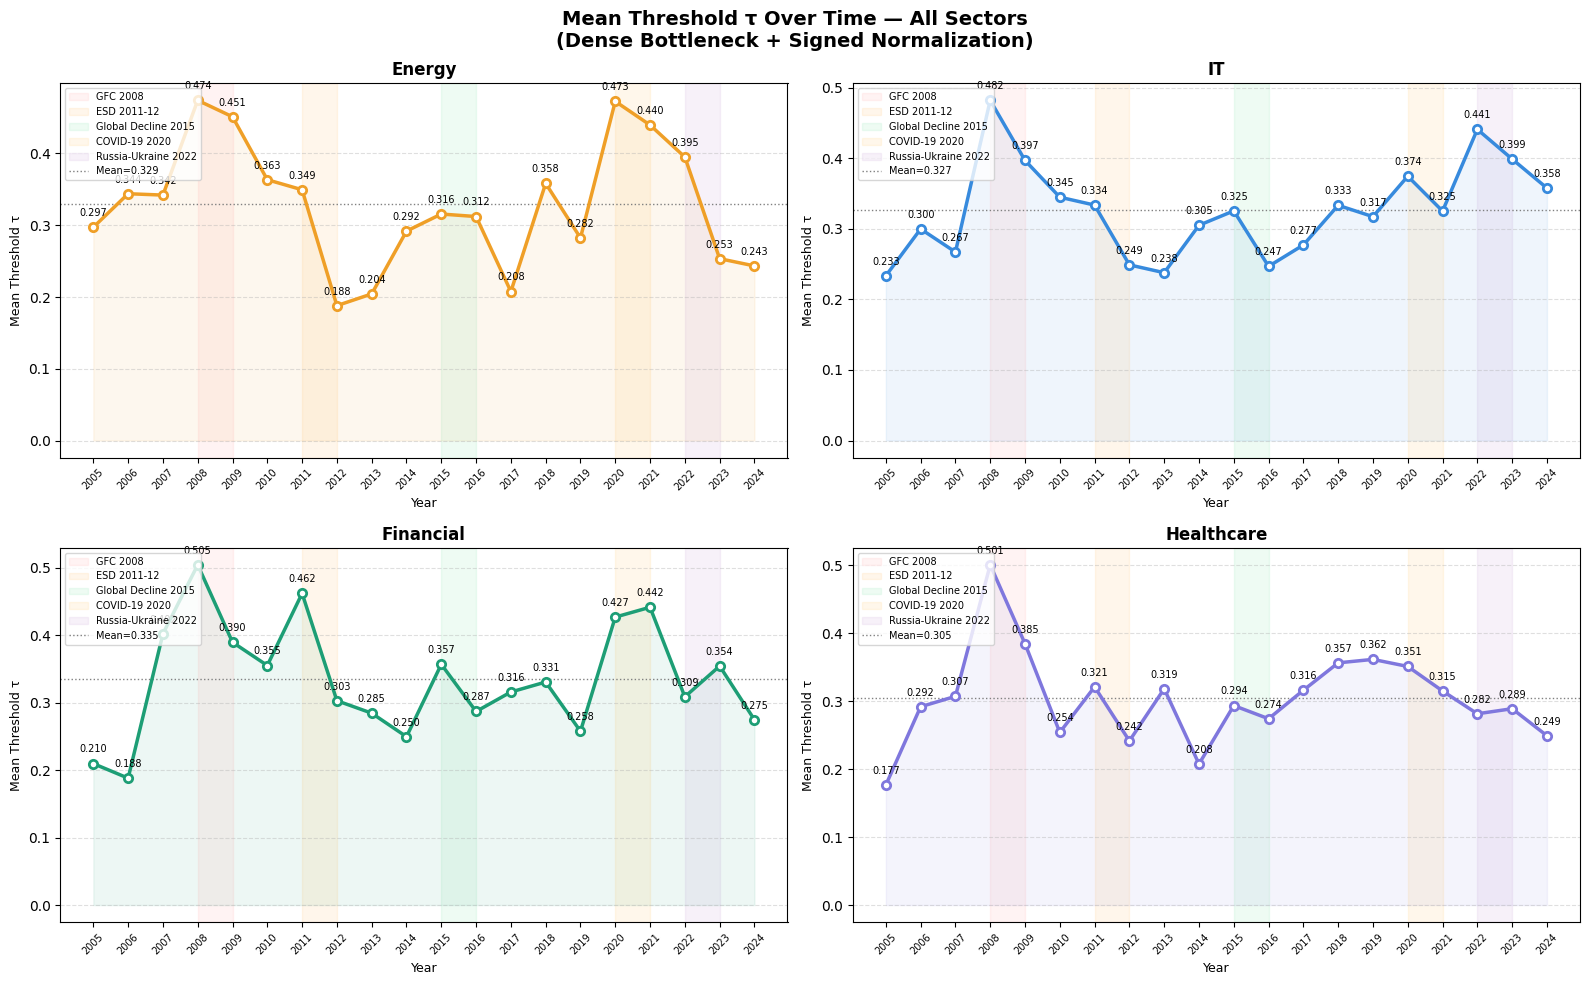


  Plot saved → /content/drive/MyDrive/MSC Thesis/BDPlots_Dense/tau_all_sectors_dense.png

✅ Phase 6 complete

 Phase 7 — Adjacency Matrix Construction

── Energy ──────────────────────────
  θ_fixed = 0.3292 + 0.2196 = 0.5488
  2005: edges=21  density=0.100  ✅
  2006: edges=32  density=0.152  ✅
  2007: edges=45  density=0.214  ✅
  2008: edges=76  density=0.362  ✅
  2009: edges=70  density=0.333  ✅
  2010: edges=45  density=0.214  ✅
  2011: edges=40  density=0.190  ✅
  2012: edges=3  density=0.014  ✅
  2013: edges=4  density=0.019  ✅
  2014: edges=26  density=0.124  ✅
  2015: edges=34  density=0.162  ✅
  2016: edges=33  density=0.157  ✅
  2017: edges=6  density=0.029  ✅
  2018: edges=42  density=0.200  ✅
  2019: edges=14  density=0.067  ✅
  2020: edges=80  density=0.381  ✅
  2021: edges=67  density=0.319  ✅
  2022: edges=48  density=0.229  ✅
  2023: edges=4  density=0.019  ✅
  2024: edges=3  density=0.014  ✅
  Mean density: 0.165
  Max density : 0.381 (2020)

── IT ────────────────────

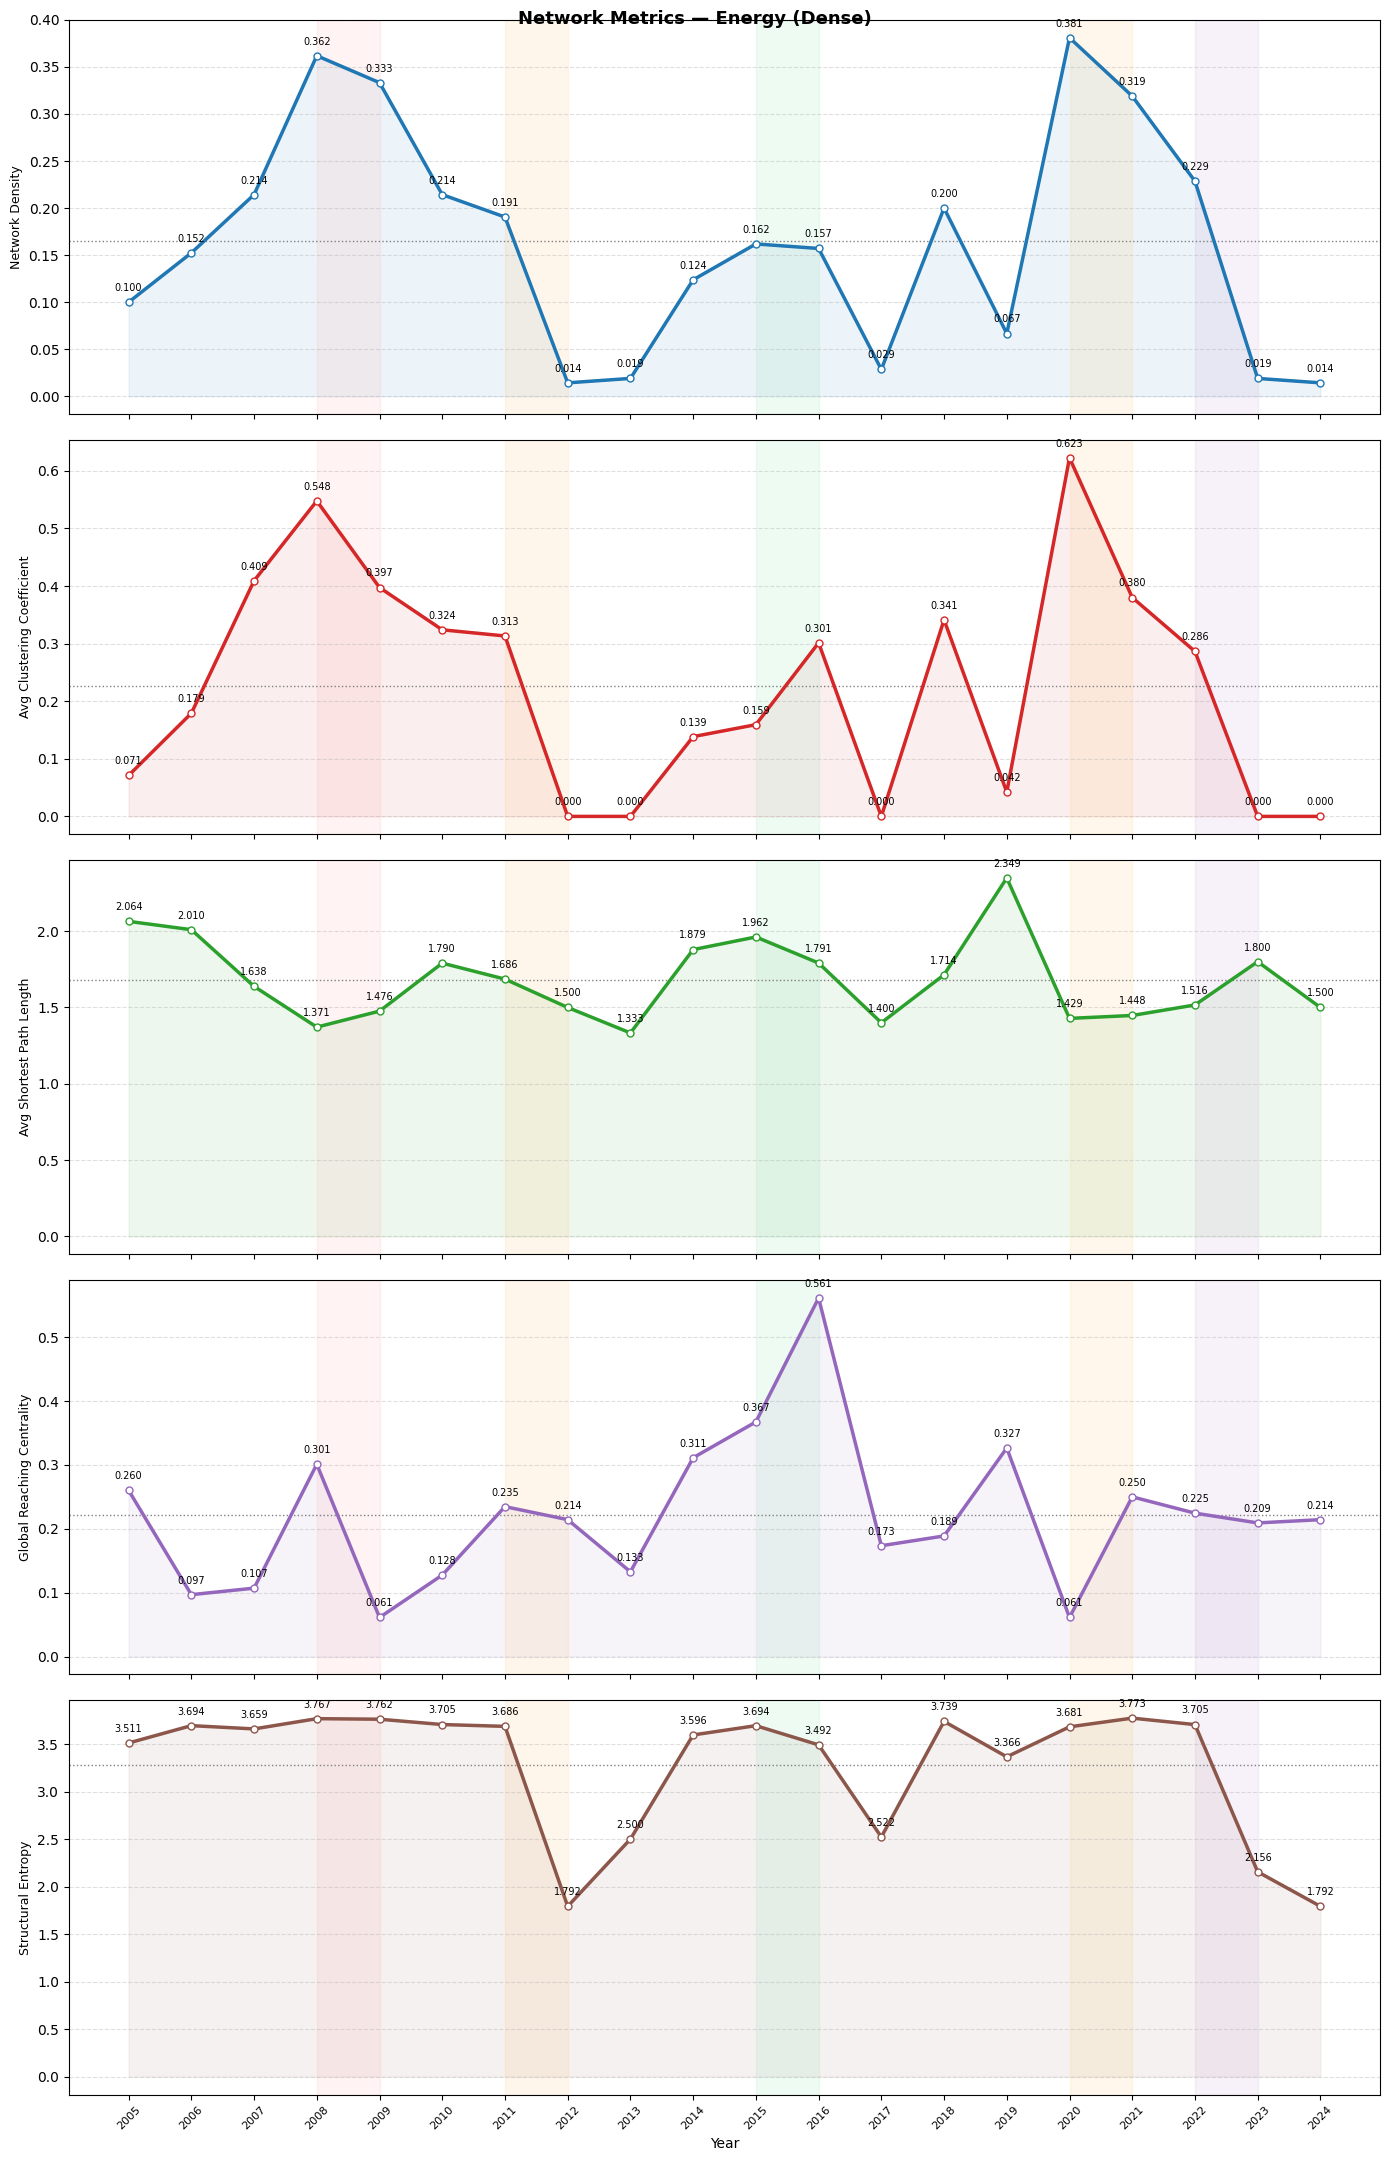


── IT ──────────────────────────
  2005: d=0.067 C=0.056 L=2.076 GRC=0.679 H=3.227
  2006: d=0.162 C=0.239 L=1.914 GRC=0.500 H=3.634
  2007: d=0.081 C=0.081 L=2.182 GRC=0.260 H=3.363
  2008: d=0.395 C=0.534 L=1.352 GRC=0.066 H=3.792
  2009: d=0.276 C=0.510 L=1.484 GRC=0.173 H=3.620
  2010: d=0.191 C=0.231 L=1.593 GRC=0.071 H=3.663
  2011: d=0.143 C=0.097 L=2.048 GRC=0.225 H=3.727
  2012: d=0.081 C=0.041 L=2.205 GRC=0.566 H=3.481
  2013: d=0.052 C=0.048 L=3.018 GRC=0.225 H=3.227
  2014: d=0.162 C=0.202 L=1.886 GRC=0.316 H=3.715
  2015: d=0.171 C=0.143 L=1.819 GRC=0.051 H=3.713
  2016: d=0.043 C=0.068 L=1.917 GRC=0.561 H=2.745
  2017: d=0.124 C=0.245 L=1.846 GRC=0.291 H=3.406
  2018: d=0.138 C=0.173 L=2.057 GRC=0.046 H=3.556
  2019: d=0.143 C=0.246 L=2.000 GRC=0.082 H=3.533
  2020: d=0.224 C=0.518 L=1.609 GRC=0.112 H=3.593
  2021: d=0.143 C=0.189 L=1.945 GRC=0.245 H=3.708
  2022: d=0.338 C=0.493 L=1.448 GRC=0.066 H=3.757
  2023: d=0.281 C=0.425 L=1.571 GRC=0.051 H=3.695
  2024: d=0.252 

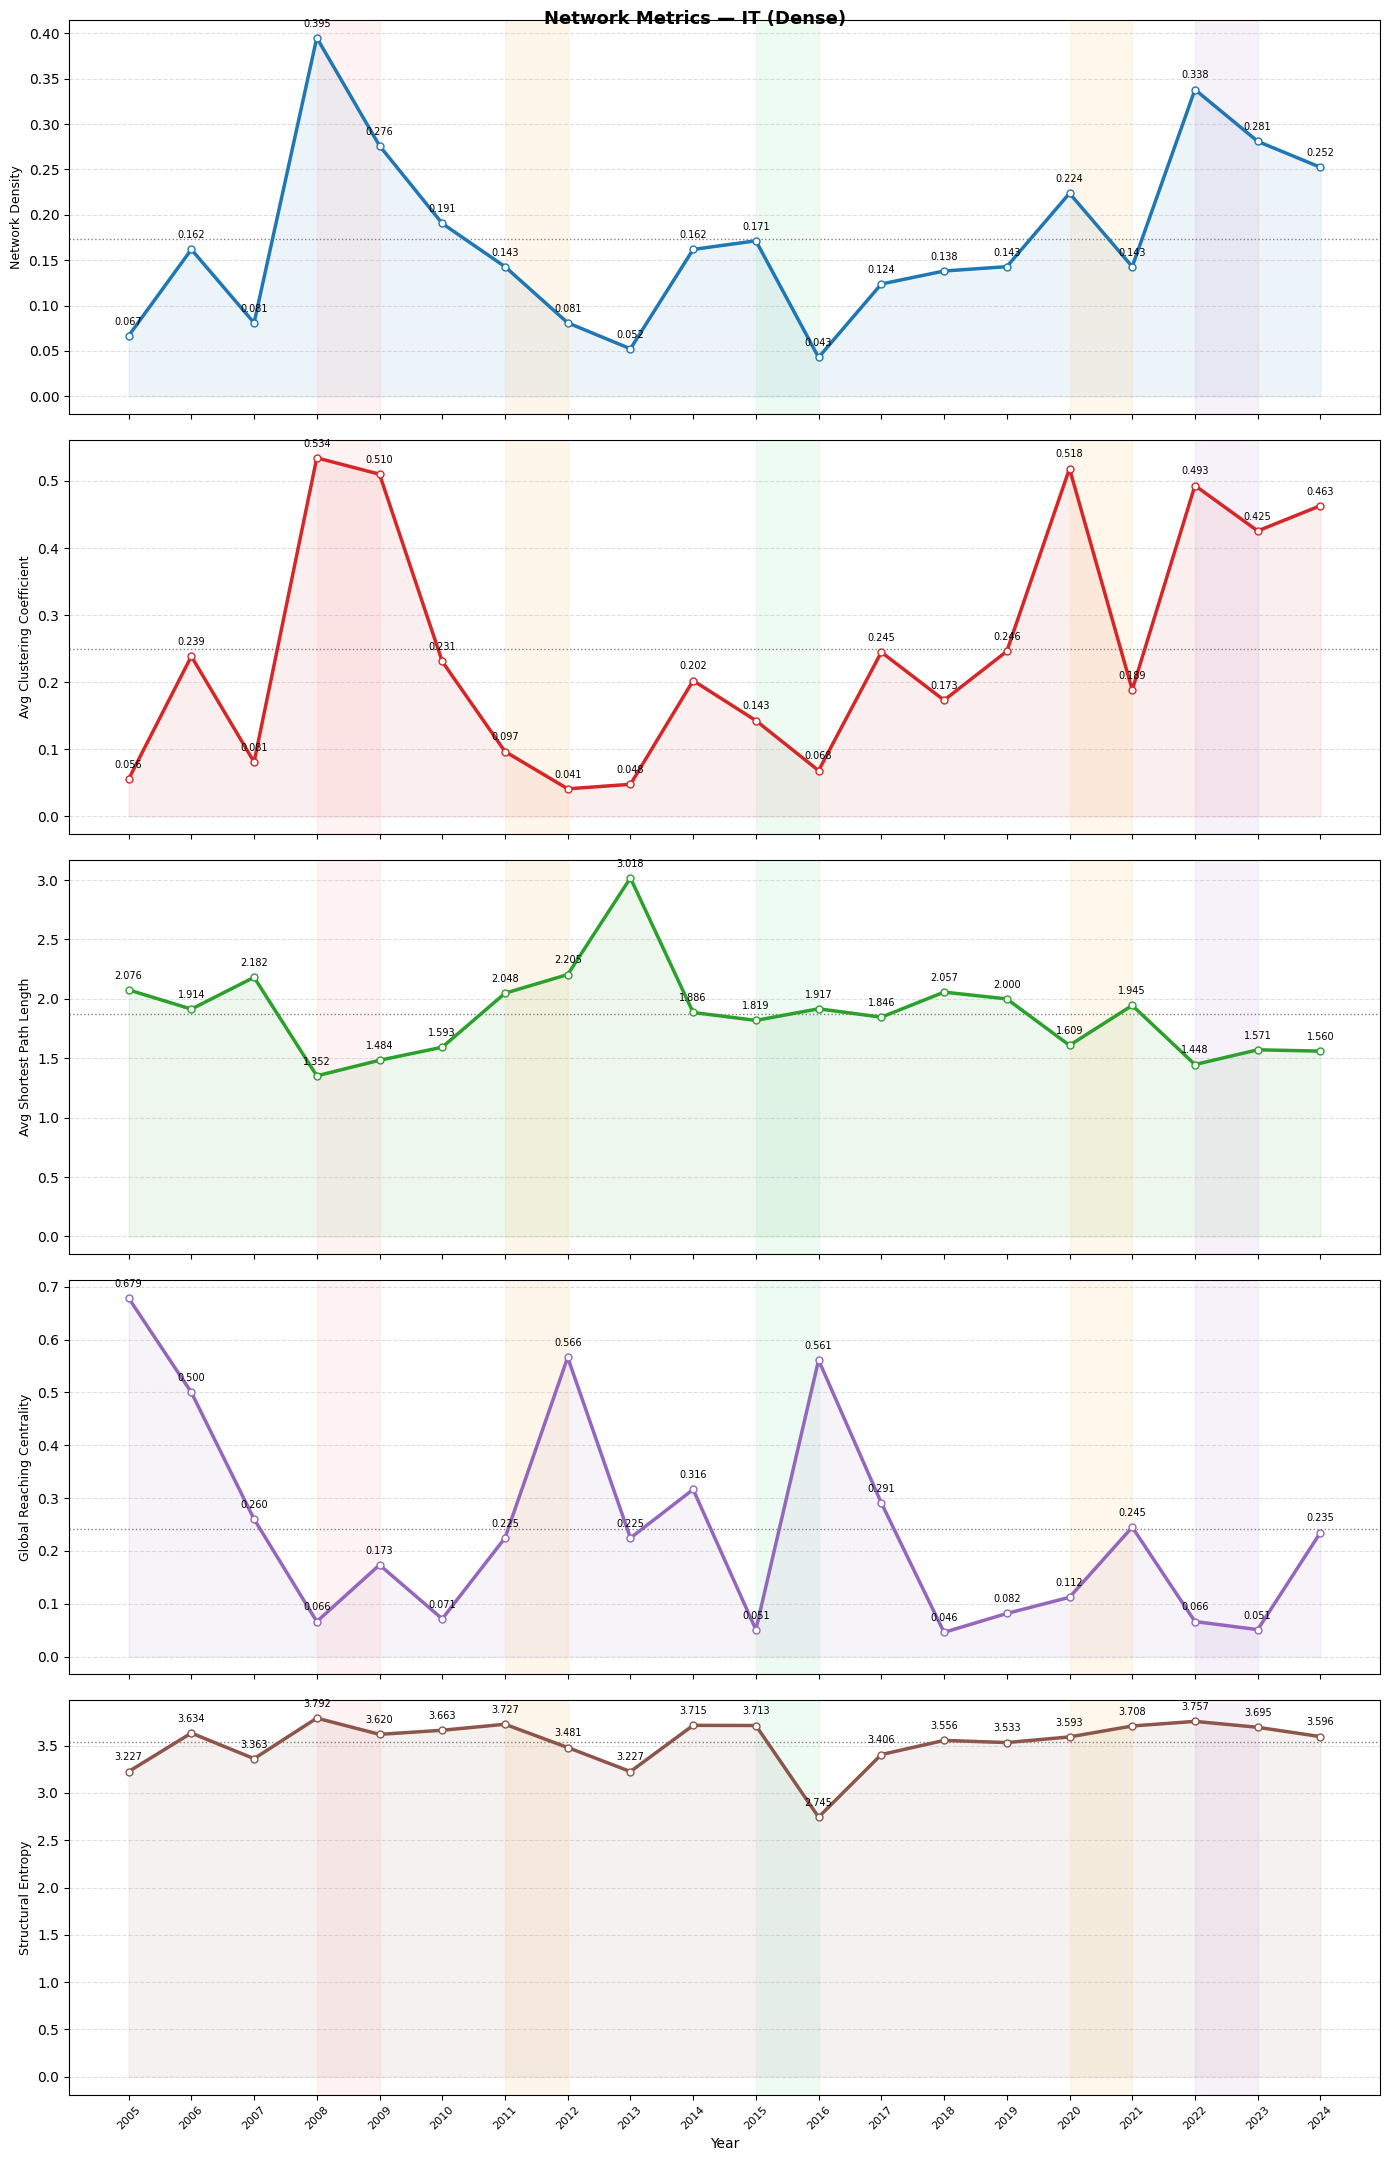


── Financial ──────────────────────────
  2005: d=0.043 C=0.000 L=1.778 GRC=0.332 H=3.192
  2006: d=0.029 C=0.000 L=1.333 GRC=0.352 H=2.618
  2007: d=0.276 C=0.460 L=1.552 GRC=0.046 H=3.688
  2008: d=0.462 C=0.620 L=1.314 GRC=0.061 H=3.787
  2009: d=0.233 C=0.380 L=1.581 GRC=0.107 H=3.713
  2010: d=0.176 C=0.251 L=1.876 GRC=0.097 H=3.692
  2011: d=0.371 C=0.530 L=1.400 GRC=0.046 H=3.747
  2012: d=0.167 C=0.174 L=1.895 GRC=0.281 H=3.690
  2013: d=0.110 C=0.024 L=2.238 GRC=0.352 H=3.686
  2014: d=0.062 C=0.020 L=1.978 GRC=0.449 H=3.119
  2015: d=0.209 C=0.228 L=1.686 GRC=0.107 H=3.778
  2016: d=0.086 C=0.053 L=2.363 GRC=0.168 H=3.425
  2017: d=0.171 C=0.361 L=1.819 GRC=0.122 H=3.637
  2018: d=0.129 C=0.096 L=1.923 GRC=0.459 H=3.626
  2019: d=0.067 C=0.088 L=1.472 GRC=0.423 H=3.254
  2020: d=0.290 C=0.432 L=1.524 GRC=0.051 H=3.751
  2021: d=0.333 C=0.498 L=1.448 GRC=0.066 H=3.753
  2022: d=0.114 C=0.108 L=2.314 GRC=0.551 H=3.701
  2023: d=0.191 C=0.199 L=1.676 GRC=0.209 H=3.739
  2024: d

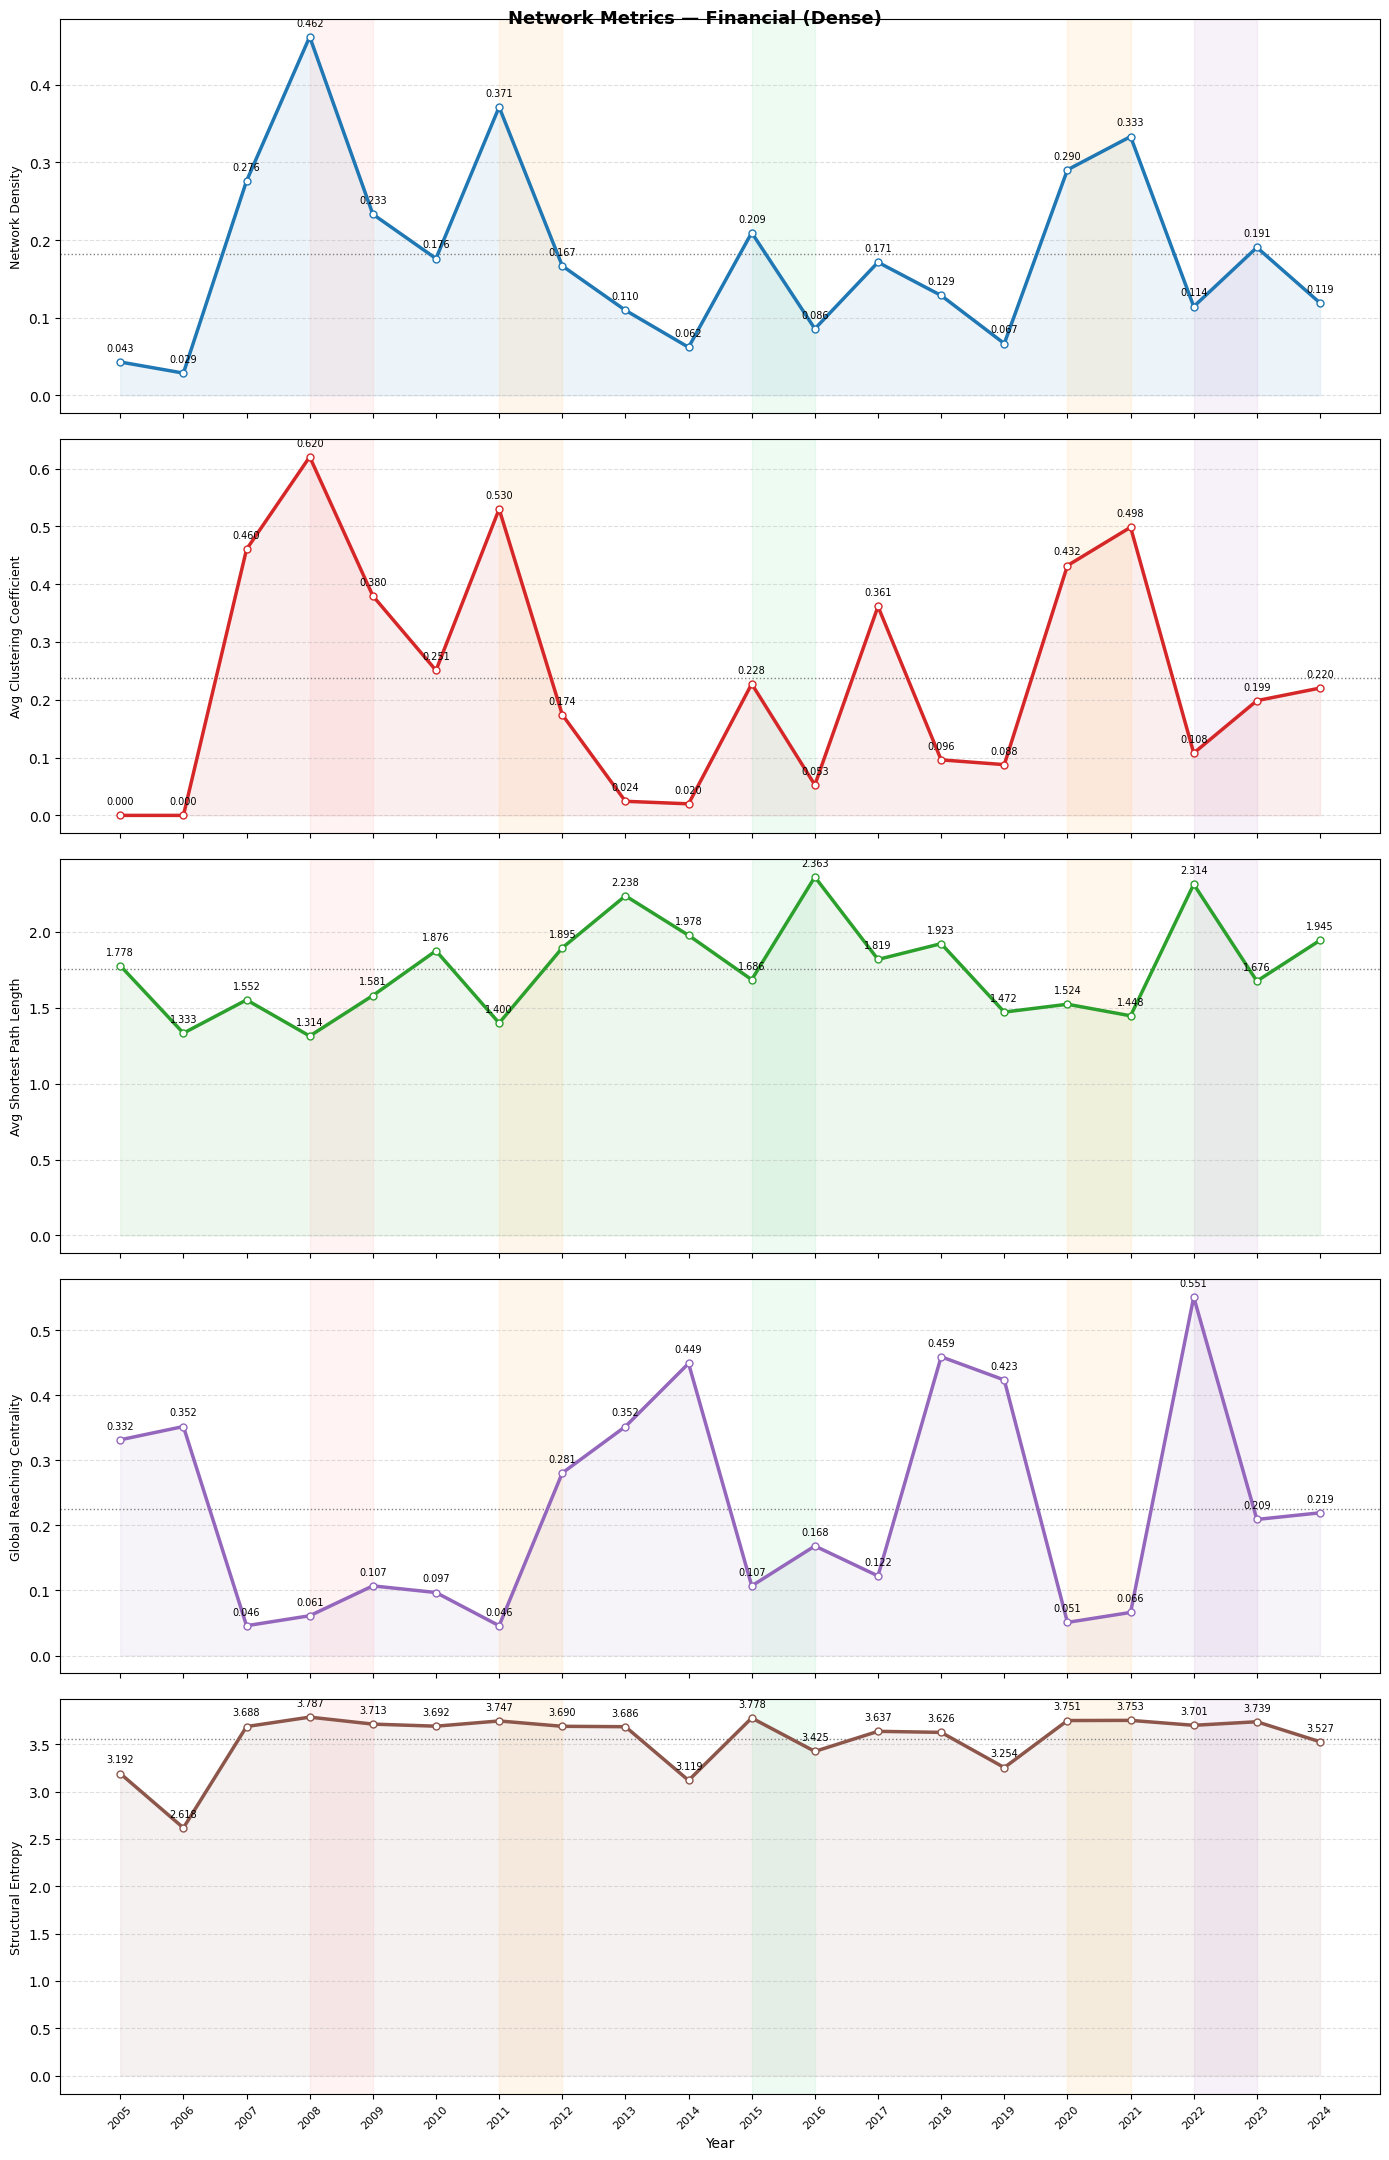


── Healthcare ──────────────────────────
  2005: d=0.043 C=0.050 L=2.306 GRC=0.388 H=2.906
  2006: d=0.119 C=0.224 L=1.885 GRC=0.612 H=3.402
  2007: d=0.195 C=0.211 L=1.695 GRC=0.367 H=3.813
  2008: d=0.471 C=0.598 L=1.267 GRC=0.056 H=3.810
  2009: d=0.271 C=0.422 L=1.514 GRC=0.209 H=3.748
  2010: d=0.071 C=0.080 L=2.018 GRC=0.209 H=3.219
  2011: d=0.171 C=0.243 L=1.867 GRC=0.041 H=3.623
  2012: d=0.062 C=0.090 L=1.754 GRC=0.204 H=3.456
  2013: d=0.229 C=0.315 L=1.619 GRC=0.117 H=3.729
  2014: d=0.038 C=0.078 L=1.333 GRC=0.240 H=2.781
  2015: d=0.133 C=0.193 L=2.038 GRC=0.602 H=3.660
  2016: d=0.110 C=0.147 L=2.051 GRC=0.571 H=3.471
  2017: d=0.181 C=0.258 L=1.924 GRC=0.051 H=3.687
  2018: d=0.252 C=0.336 L=1.591 GRC=0.051 H=3.784
  2019: d=0.248 C=0.360 L=1.600 GRC=0.061 H=3.755
  2020: d=0.205 C=0.404 L=1.582 GRC=0.301 H=3.588
  2021: d=0.157 C=0.172 L=2.000 GRC=0.423 H=3.748
  2022: d=0.129 C=0.146 L=1.795 GRC=0.184 H=3.534
  2023: d=0.138 C=0.143 L=1.744 GRC=0.281 H=3.599
  2024: 

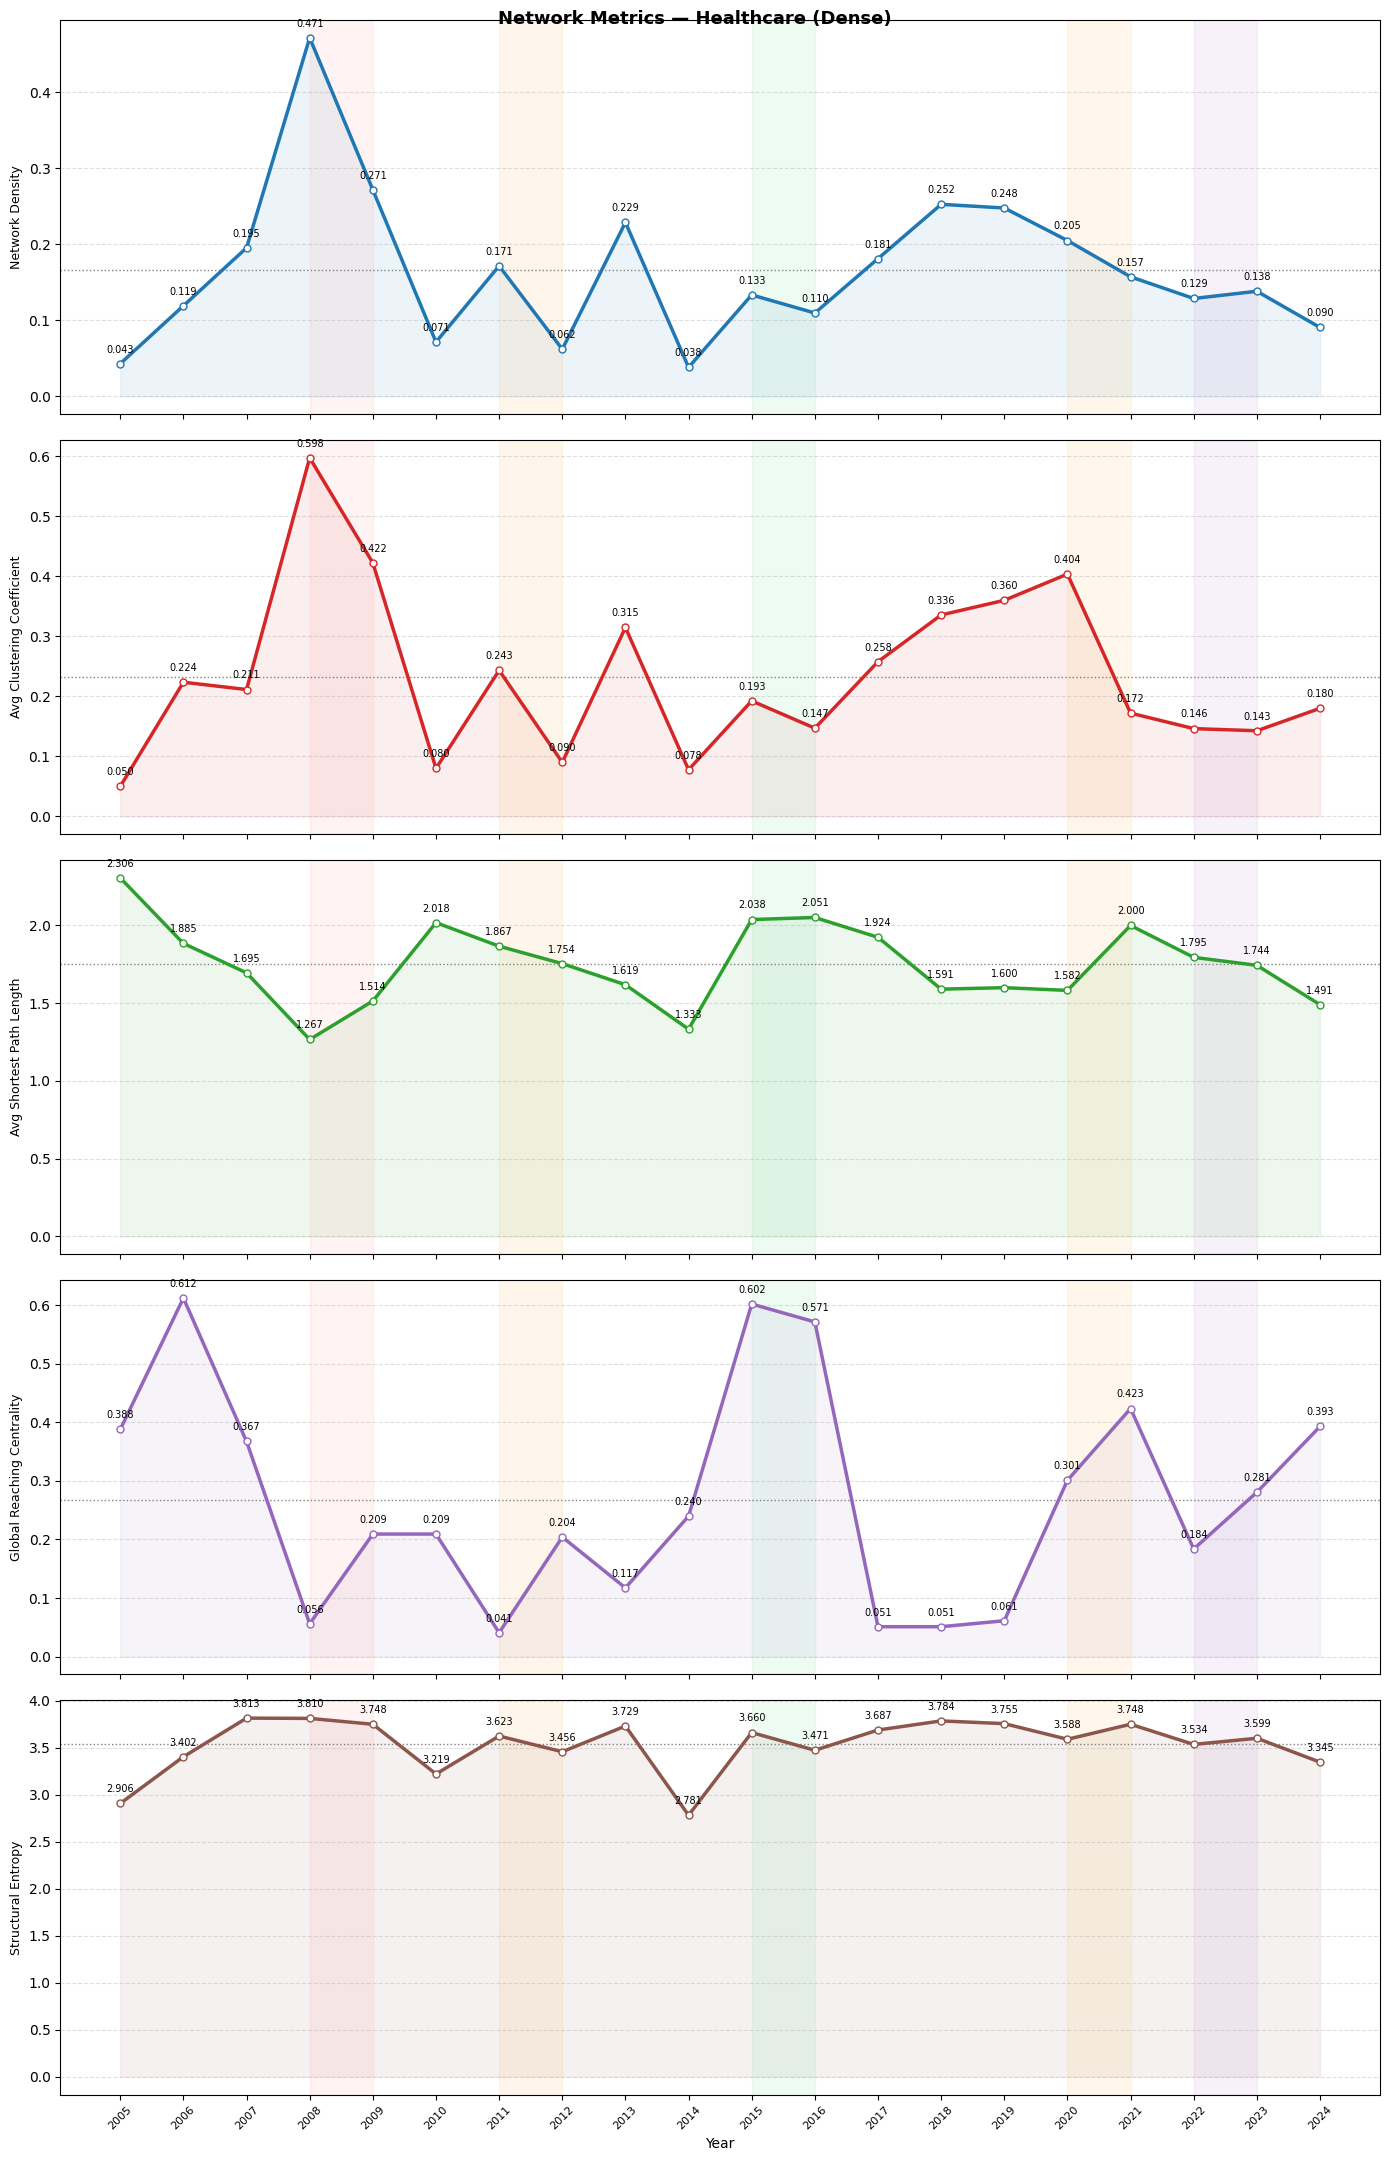


  Cross-sector summary:
    Sector     Metric   Mean    Max  MaxYear    Min  MinYear
    Energy    density 0.1650 0.3810     2020 0.0143     2012
    Energy clustering 0.2257 0.6226     2020 0.0000     2012
    Energy   avg_path 1.6828 2.3485     2019 1.3333     2013
    Energy        grc 0.2212 0.5612     2016 0.0612     2009
    Energy    entropy 3.2797 3.7731     2021 1.7925     2012
        IT    density 0.1734 0.3952     2008 0.0429     2016
        IT clustering 0.2501 0.5344     2008 0.0411     2012
        IT   avg_path 1.8765 3.0182     2013 1.3524     2008
        IT        grc 0.2411 0.6786     2005 0.0459     2018
        IT    entropy 3.5375 3.7916     2008 2.7448     2016
 Financial    density 0.1819 0.4619     2008 0.0286     2006
 Financial clustering 0.2372 0.6203     2008 0.0000     2005
 Financial   avg_path 1.7558 2.3626     2016 1.3143     2008
 Financial        grc 0.2250 0.5510     2022 0.0459     2007
 Financial    entropy 3.5561 3.7873     2008 2.6175     2006

In [ ]:
# ══════════════════════════════════════════════════════════
# RUN ALL PHASES
# ══════════════════════════════════════════════════════════

print("=" * 60)
print(" Running Phases 5 → 8 with Dense Models")
print("=" * 60)

extract_all_weights()       # Phase 5
plot_tau_all_sectors()      # Phase 6
build_adjacency_all()       # Phase 7
compute_metrics_all()       # Phase 8

print("\n" + "="*60)
print(" All phases complete!")
print("="*60)
print(f"  W matrices  → {WEIGHT_DIR}")
print(f"  Adjacency   → {ADJ_DIR}")
print(f"  Metrics     → {METRICS_DIR}")
print(f"  Plots       → {PLOT_DIR}")
print(f"\n  Next: Phase 10 — Multilayer Network Construction")